# Tutorial 13 — Extending the Packer and Inspecting Rotamers

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/13_extending_the_packer.ipynb)

This advanced tutorial subclasses `PackerPalette` to define an application-specific amino-acid alphabet, inspects the resulting discrete rotamer ensemble before annealing, exports that ensemble as multi-model PDB text, and verifies the final packed structure.

## Learning objectives

By the end, you will be able to:

- explain the distinct roles of `PackerPalette`, `PackerTask`, samplers, and annealing;
- implement a palette that only removes choices from the default compatible set;
- audit allowed identities and per-identity rotamer counts before packing;
- visualize χ-space and individual candidate conformers interactively;
- export low-level rotamer coordinates without confusing them with packing outcomes.

## Before you begin

Complete [Packing and a Small Mutation Scan](04_packing_and_mutation_scan.ipynb). This notebook uses low-level rotamer construction intended for developers and diagnostics. Candidate enumeration is deterministic for a fixed task, but simulated annealing is a stochastic assignment search; candidate counts and final sequence identities answer different questions.


## Setup

**Run in Colab:** Use the badge above, select **Runtime → Change runtime type → T4 GPU**, then **Runtime → Run all**. The setup installs TMol and downloads any listed fixtures; allow extra time for installation and the first calculation. For local execution, follow the [installation guide](../installation.md) and use a kernel with TMol installed.

The notebook loads the first ten residues of the checked-in 1UBQ structure and optimizes polar hydrogens before interpreting all-atom scores. Only one internal position is designable, keeping CPU documentation execution practical.


In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(["tmol/tests/data/cif/1UBQ.cif"])


In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
import tempfile
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure.io import load_structure

import tmol
from tmol.database import ParameterDatabase
from tmol.io import pose_stack_from_biotite
from tmol.numeric import coord_dihedrals
from tmol.ops import res_mask_to_coord_mask
from tmol.pack import PackerPalette, PackerTask, SetPackerTask, pack_rotamers
from tmol.pack.rotamer import FixedAAChiSampler, IncludeCurrentSampler, build_rotamers
from tmol.pack.rotamer.dunbrack import create_dunbrack_sampler_from_database
from tmol.score import beta2016_score_function

SEED = 20260910
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
warnings.filterwarnings(
    "ignore", message=r"Sparse invariant checks are implicitly disabled.*"
)

device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol/tests/data/cif/1UBQ.cif"

parameter_db = ParameterDatabase.get_default()
atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 10)]
diagnostics = StringIO()
try:
    with redirect_stdout(diagnostics), redirect_stderr(diagnostics):
        pose_stack = pose_stack_from_biotite(
            protein_slice,
            device,
            param_db=parameter_db,
            no_optH=False,
        )
except Exception:
    print(diagnostics.getvalue())
    raise
score_function = beta2016_score_function(device, param_db=parameter_db)


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


def total_score(pose):
    scorer = score_function.render_whole_pose_scoring_module(pose)
    return float(scorer(pose.coords).detach().cpu()[0])


print(
    f"TMol {tmol.__version__}; PyTorch {torch.__version__}; "
    f"device={device}; blocks={pose_stack.max_n_blocks}"
)


TMol 0.1.56; PyTorch 2.13.0+cu132; device=cuda:0; blocks=10


## Define an alphabet by subclassing `PackerPalette`

A palette creates the initial compatible block-type choices for every original type. A task may then disable positions or remove more choices, but it must not re-enable a choice already rejected by the palette. The subclass below starts from TMol's default L-amino-acid compatibility rules, keeps a hydrophobic design alphabet, and always retains the original block type so every position has at least one valid choice.

The target is block 5, lysine in this 1UBQ slice. Every other block is disabled. This makes the example an audit of one design position rather than a claim about an optimized protein sequence.


In [3]:
class HydrophobicPalette(PackerPalette):
    """Allow a small hydrophobic alphabet plus each original block type."""

    def __init__(self, allowed_name3s=("ALA", "VAL", "LEU", "ILE", "PHE")):
        super().__init__()
        self.allowed_name3s = frozenset(allowed_name3s)

    def block_types_from_original(self, pbt, orig):
        n_allowed, allowed, is_original = super().block_types_from_original(
            pbt, orig
        )
        in_alphabet = torch.tensor(
            [
                block_type.name3 in self.allowed_name3s
                for block_type in pbt.active_block_types
            ],
            dtype=torch.bool,
            device=pbt.device,
        )
        real_choice = allowed >= 0
        keep = torch.zeros_like(allowed, dtype=torch.bool)
        keep[real_choice] = in_alphabet[allowed[real_choice]]
        keep = (keep | is_original) & real_choice

        order = torch.argsort((~keep).to(torch.int64), dim=2, stable=True)
        allowed = torch.gather(allowed, 2, order)
        is_original = torch.gather(is_original, 2, order)
        keep = torch.gather(keep, 2, order)
        allowed = torch.where(keep, allowed, torch.full_like(allowed, -1))
        is_original = is_original & keep
        n_allowed = keep.sum(dim=2)
        return n_allowed, allowed, is_original


target_block = 5
palette = HydrophobicPalette()
design_task = PackerTask(pose_stack, palette)
design_region = torch.zeros(
    (pose_stack.n_poses, pose_stack.max_n_blocks),
    dtype=torch.bool,
    device=device,
)
design_region[:, target_block] = True
design_task.disable_packing_by_block_mask(~design_region)

design_task.add_conformer_sampler(
    create_dunbrack_sampler_from_database(parameter_db, device)
)
design_task.add_conformer_sampler(FixedAAChiSampler())
design_task.add_conformer_sampler(IncludeCurrentSampler())

considered = design_task.per_block_considered_block_types[0, target_block]
allowed_mask = design_task.per_block_is_block_type_allowed[0, target_block]
identity_rows = []
for slot, (type_index, is_allowed) in enumerate(
    zip(considered.detach().cpu().tolist(), allowed_mask.detach().cpu().tolist())
):
    if type_index < 0:
        continue
    block_type = pose_stack.packed_block_types.active_block_types[type_index]
    identity_rows.append(
        {
            "choice_slot": slot,
            "block_type": block_type.name,
            "name3": block_type.name3,
            "allowed_after_palette": bool(is_allowed),
            "is_original": type_index == int(pose_stack.block_type_ind64[0, target_block]),
        }
    )
identity_frame = pd.DataFrame(identity_rows)
show_table(identity_frame)
assert identity_frame.loc[identity_frame.allowed_after_palette, "name3"].isin(
    palette.allowed_name3s | {pose_stack.block_type(0, target_block).name3}
).all()


In [4]:
target_mask = torch.zeros_like(design_region)
target_mask[:, target_block] = True
target_atom_mask = res_mask_to_coord_mask(pose_stack, target_mask)
try:
    target_viewer = tmol.view(
        pose_stack,
        highlighted=target_atom_mask[pose_stack.real_atoms],
        highlight_color="#f58518",
        width=720,
        height=390,
    )
    print(
        f"Orange target: block {target_block}, "
        f"{pose_stack.block_type(0, target_block).name3}"
    )
    target_viewer.show()
except ImportError as exc:
    print("Interactive target viewer unavailable:", exc)


Orange target: block 5, LYS


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Expected observations.** The table distinguishes considered choices from choices still allowed after applying the palette. Only the whitelist and the original LYS remain. Terminal or chemically incompatible variants are absent because the default palette rejected them before the subclass filtered the set.


## Enumerate and audit rotamers before annealing

`SetPackerTask` freezes the task masks. `build_rotamers()` then combines every configured sampler into a coordinate ensemble. This is the right stage for auditing whether a custom alphabet and sampling policy produced the intended search space.

The identity-count plot answers how many candidates each residue type contributes. The χ plot shows their geometry. It does not show probabilities, energies, an annealing trajectory, or statistically independent samples.


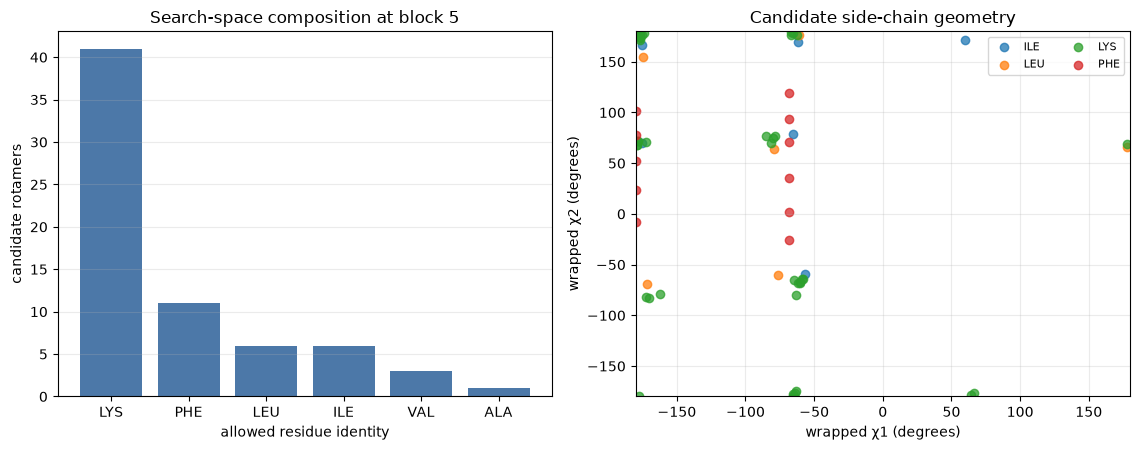

In [5]:
rotamer_pose, rotamer_set = build_rotamers(
    pose_stack,
    SetPackerTask.from_packer_task(design_task),
    pose_stack.packed_block_types.chem_db,
)
target_rotamer_count = int(rotamer_set.n_rots_for_block[0, target_block])
target_rotamer_offset = int(rotamer_set.rot_offset_for_block[0, target_block])

rotamer_rows = []
for local_rotamer in range(target_rotamer_count):
    rotamer_index = target_rotamer_offset + local_rotamer
    block_type_index = int(rotamer_set.block_type_ind_for_rot[rotamer_index])
    block_type = rotamer_pose.packed_block_types.active_block_types[
        block_type_index
    ]
    coordinate_offset = int(rotamer_set.coord_offset_for_rot[rotamer_index])
    row = {
        "local_rotamer": local_rotamer,
        "rotamer_index": rotamer_index,
        "block_type": block_type.name,
        "name3": block_type.name3,
    }
    for torsion_index in block_type.sc_torsions:
        atom_indices = block_type.ordered_torsions[torsion_index, :, 0]
        if np.any(atom_indices < 0):
            continue
        coordinates = rotamer_set.coords[
            coordinate_offset
            + torch.as_tensor(atom_indices, dtype=torch.long, device=device)
        ].double()
        radians = coord_dihedrals(
            coordinates[0:1],
            coordinates[1:2],
            coordinates[2:3],
            coordinates[3:4],
        )[0]
        name = block_type.torsions[torsion_index].name
        row[f"{name}_degrees"] = float(torch.rad2deg(radians).detach().cpu())
    rotamer_rows.append(row)

rotamer_frame = pd.DataFrame(rotamer_rows)
identity_counts = (
    rotamer_frame.groupby("name3", as_index=False)
    .size()
    .rename(columns={"size": "candidate_rotamers"})
    .sort_values("candidate_rotamers", ascending=False)
)
show_table(identity_counts)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
axes[0].bar(identity_counts.name3, identity_counts.candidate_rotamers, color="#4c78a8")
axes[0].set(
    xlabel="allowed residue identity",
    ylabel="candidate rotamers",
    title=f"Search-space composition at block {target_block}",
)
axes[0].grid(axis="y", alpha=0.25)

if {"chi1_degrees", "chi2_degrees"}.issubset(rotamer_frame.columns):
    for name3, values in rotamer_frame.dropna(
        subset=["chi1_degrees", "chi2_degrees"]
    ).groupby("name3"):
        axes[1].scatter(
            (values.chi1_degrees + 180.0) % 360.0 - 180.0,
            (values.chi2_degrees + 180.0) % 360.0 - 180.0,
            label=name3,
            alpha=0.75,
        )
    axes[1].legend(fontsize=8, ncol=2)
axes[1].set(
    xlim=(-180, 180),
    ylim=(-180, 180),
    xlabel="wrapped χ1 (degrees)",
    ylabel="wrapped χ2 (degrees)",
    title="Candidate side-chain geometry",
)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

assert target_rotamer_count == int(identity_counts.candidate_rotamers.sum())


## Inspect individual candidates and export the ensemble

Rotamer coordinates are stored in one packed tensor. The helper below turns each target candidate into a single-residue PDB model for inspection, then concatenates those models into standard multi-model PDB text. This diagnostic export intentionally contains only the candidate residue; neighboring coordinates and energies belong to later packing stages.

The interactive selector is capped at twelve candidates to keep the rendered page compact. The complete text remains available as `rotamer_ensemble_pdb` and is written to a temporary file as an executable export example.


In [6]:
def rotamer_pdb_body(rotamer_index):
    block_type_index = int(rotamer_set.block_type_ind_for_rot[rotamer_index])
    block_type = rotamer_pose.packed_block_types.active_block_types[
        block_type_index
    ]
    coordinate_offset = int(rotamer_set.coord_offset_for_rot[rotamer_index])
    lines = []
    for atom_index, atom in enumerate(block_type.atoms, start=1):
        x, y, z = rotamer_set.coords[
            coordinate_offset + atom_index - 1
        ].detach().cpu().tolist()
        element = "".join(character for character in atom.name if character.isalpha())[:1]
        lines.append(
            f"ATOM  {atom_index:5d} {atom.name:<4} {block_type.name3:>3} A"
            f"{target_block + 1:4d}    {x:8.3f}{y:8.3f}{z:8.3f}"
            f"  1.00  0.00          {element:>2}"
        )
    return block_type.name3, "\n".join(lines) + "\n"


models = []
candidate_views = {}
candidate_notes = {}
for local_rotamer in range(target_rotamer_count):
    rotamer_index = target_rotamer_offset + local_rotamer
    name3, body = rotamer_pdb_body(rotamer_index)
    models.append(f"MODEL     {local_rotamer + 1:4d}\n{body}ENDMDL\n")
    if local_rotamer < 12:
        label = f"{local_rotamer:02d}: {name3}"
        candidate_views[label] = body + "END\n"
        candidate_notes[label] = "One enumerated side-chain candidate; no packing score applied"

rotamer_ensemble_pdb = "".join(models)
export_dir = Path(tempfile.mkdtemp(prefix="tmol-rotamer-tutorial-"))
export_path = export_dir / "block5_rotamer_ensemble.pdb"
export_path.write_text(rotamer_ensemble_pdb)
print(
    f"wrote {target_rotamer_count} models to {export_path.name}; "
    f"bytes={export_path.stat().st_size}"
)
print("\n".join(rotamer_ensemble_pdb.splitlines()[:8]))

try:
    display(
        tmol.switchable_view(
            candidate_views,
            notes=candidate_notes,
            width=620,
            height=360,
        )
    )
except ImportError as exc:
    print("Interactive rotamer selector unavailable:", exc)


wrote 68 models to block5_rotamer_ensemble.pdb; bytes=112728
MODEL        1
ATOM      1 N    ALA A   6      27.751  35.867  13.740  1.00  0.00           N
ATOM      2 CA   ALA A   6      27.691  37.315  14.143  1.00  0.00           C
ATOM      3 C    ALA A   6      28.469  37.475  15.420  1.00  0.00           C
ATOM      4 O    ALA A   6      28.213  36.753  16.411  1.00  0.00           O
ATOM      5 CB   ALA A   6      26.260  37.797  14.331  1.00  0.00           C
ATOM      6 H    ALA A   6      27.087  35.218  14.137  1.00  0.00           H
ATOM      7 HA   ALA A   6      28.141  37.914  13.350  1.00  0.00           H


**Expected observations.** Switching candidates changes side-chain identity and/or χ geometry while preserving the local backbone frame used to construct the rotamers. The multi-model file is a geometry audit artifact. It is not a trajectory, an ordered energy ranking, or a collection of independently packed structures.


## Run the assignment search and verify the result

Only now does `pack_rotamers()` score interacting candidates and run the annealer. The result must belong to the audited palette, every non-target identity must remain unchanged, and backbone coordinates must remain fixed. CPU and CUDA use different stochastic search implementations, so the chosen identity and score need not match across devices.


In [7]:
input_score = total_score(pose_stack)
torch.manual_seed(SEED)
packed_pose = pack_rotamers(
    pose_stack, score_function, design_task, verbose=False
)
packed_score = total_score(packed_pose)
original_identity = pose_stack.block_type(0, target_block).name3
packed_identity = packed_pose.block_type(0, target_block).name3

result_frame = pd.DataFrame(
    [
        {
            "stage": "input",
            "target_identity": original_identity,
            "weighted_score_units": input_score,
            "score_change": 0.0,
        },
        {
            "stage": "custom-palette packing",
            "target_identity": packed_identity,
            "weighted_score_units": packed_score,
            "score_change": packed_score - input_score,
        },
    ]
)
show_table(result_frame)

for block in range(pose_stack.max_n_blocks):
    if block != target_block:
        assert packed_pose.block_type(0, block).name3 == pose_stack.block_type(0, block).name3
assert packed_identity in palette.allowed_name3s | {original_identity}

# N, CA, C, and O coordinates are unaffected by side-chain packing.
max_backbone_change = 0.0
for block in range(pose_stack.max_n_blocks):
    before_type = pose_stack.block_type(0, block)
    after_type = packed_pose.block_type(0, block)
    before_offset = int(pose_stack.block_coord_offset64[0, block])
    after_offset = int(packed_pose.block_coord_offset64[0, block])
    for atom_name in ("N", "CA", "C", "O"):
        delta = (
            packed_pose.coords[0, after_offset + after_type.atom_to_idx[atom_name]]
            - pose_stack.coords[0, before_offset + before_type.atom_to_idx[atom_name]]
        )
        max_backbone_change = max(
            max_backbone_change,
            float(torch.linalg.vector_norm(delta).detach().cpu()),
        )
print(f"maximum backbone coordinate change: {max_backbone_change:.6f} Å")
assert max_backbone_change < 1e-4


maximum backbone coordinate change: 0.000004 Å


In [8]:
try:
    display(
        tmol.switchable_view(
            {
                f"input ({original_identity})": pose_stack,
                f"packed ({packed_identity})": packed_pose,
            },
            notes={
                f"input ({original_identity})": f"weighted score {input_score:.3f}",
                f"packed ({packed_identity})": (
                    f"weighted score {packed_score:.3f}; "
                    f"change {packed_score - input_score:+.3f}"
                ),
            },
            width=720,
            height=400,
        )
    )
except ImportError as exc:
    print("Interactive packed comparison unavailable:", exc)


**Expected observations.** The packed target is either one hydrophobic alphabet member or the retained original LYS. The rest of the sequence and all backbone coordinates remain fixed. A lower score is a result for this one stochastic, locally packed state—not a stability prediction or a claim that the selected mutation is experimentally favorable.

## Extension checklist

1. Start from `super().block_types_from_original()` so chemical compatibility is preserved.
2. Only remove `True` choices; never manufacture a block-type index that was not considered.
3. Retain at least one valid choice at every real block.
4. Audit identity and rotamer counts before annealing.
5. Distinguish deterministic candidate enumeration from stochastic assignment search.
6. Verify unchanged identities and coordinates outside the intended region.

## Exercises

1. Add TYR and TRP to the palette and compare how identity and rotamer counts change.
2. Apply `or_expand_chi(0)` only at the target and compare χ-space before and after expansion.
3. Pack several identical poses in one batch and summarize the distribution of selected identities without treating CPU and CUDA outcomes as the same protocol.

## References

- [Tutorial 04 — Packing and a Small Mutation Scan](04_packing_and_mutation_scan.ipynb)
- [Tutorial 06 — FastRelax](06_fast_relax.ipynb)
- [Packing API](../api/pack.rst)
- [Pose API](../api/pose.rst)
